# Vertical acceleration correction

In [8]:
import cmocean
import matplotlib.pyplot as plt
import pandas as pd
import plotly.io as pio
import seaborn as sns
import verde as vd

import airbornegeo

pio.renderers.default = "notebook"

## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_survey`. It has a pre-compute vertical acceleration correction, which we will compare our computed values to.

In [2]:
data_df_full = pd.read_csv("data/AGAP_gravity_survey.csv")
print(data_df_full.columns)
data_df_full["index"] = data_df_full.index
data_df_full.head()

Index(['Lon', 'Lat', 'Height_WGS1984', 'Date', 'Time', 'ST', 'CC', 'RB',
       'XACC', 'LACC', 'Still', 'Base', 'ST_real', 'Beam_vel', 'rec_grav',
       'Abs_grav', 'VaccCor', 'EotvosCor', 'LatCor', 'FaCor', 'HaccCor',
       'Free_air', 'FAA_filt', 'FAA_clip', 'Level_cor', 'FAA_level',
       'Fa_4600m', 'easting', 'northing', 'line_name', 'line', 'unixtime'],
      dtype='str')


,Lon,Lat,Height_WGS1984,Date,Time,ST,CC,RB,XACC,LACC,...,FAA_clip,Level_cor,FAA_level,Fa_4600m,easting,northing,line_name,line,unixtime,index
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,49.38,7.03,42.4,40.8,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09,0
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,49.45,7.04,42.4,40.8,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09,1
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,49.52,7.04,42.5,40.9,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09,2
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,49.58,7.03,42.5,40.9,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09,3
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,49.65,7.04,42.6,41.0,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09,4


In [3]:
# get only the raw columns
# we will perform the corrections ourselves and compare to their values
data_df = data_df_full[
    [
        "VaccCor",
        "Height_WGS1984",
        "easting",
        "northing",
        "unixtime",
        "line",
        "index",
    ]
]
data_df.head()

,VaccCor,Height_WGS1984,easting,northing,unixtime,line,index
0,5826.01,4156.1,1.000024e+06,226237.330771,1.229507e+09,1,0
1,19948.92,4156.0,1.000083e+06,226246.631269,1.229507e+09,1,1
2,16840.24,4156.1,1.000142e+06,226255.809132,1.229507e+09,1,2
3,-2695.10,4156.4,1.000201e+06,226264.969079,1.229507e+09,1,3
4,4457.47,4156.6,1.000260e+06,226274.156809,1.229507e+09,1,4


## Vertical acceleration

In [4]:
data_df["vertical_acceleration"] = airbornegeo.vertical_acceleration(
    data_df,
    groupby_column="line",
    time_column="unixtime",
    height_column="Height_WGS1984",
    # smoothing_window=3,
    time_threshold=10,
)

# convert from m/s^2 to mGals
data_df["vertical_acceleration"] *= 10**5
data_df.head()

/home/sungw937/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/pandas/core/arrays/timedeltas.py:1163: RuntimeWarning: invalid value encountered in cast
  int_data = data.astype(np.int64)
Segments: 100%|██████████| 167/167 [00:00<00:00, 1322.29it/s]


,VaccCor,Height_WGS1984,easting,northing,unixtime,line,index,vertical_acceleration
0,5826.01,4156.1,1.000024e+06,226237.330771,1.229507e+09,1,0,NaN
1,19948.92,4156.0,1.000083e+06,226246.631269,1.229507e+09,1,1,NaN
2,16840.24,4156.1,1.000142e+06,226255.809132,1.229507e+09,1,2,20000.0
3,-2695.10,4156.4,1.000201e+06,226264.969079,1.229507e+09,1,3,20000.0
4,4457.47,4156.6,1.000260e+06,226274.156809,1.229507e+09,1,4,-10000.0


## Compare the results

In [5]:
data_df_full = data_df_full.drop(columns=["vertical_acceleration"], errors="ignore")
data_df_full = data_df_full.merge(
    data_df[["index", "vertical_acceleration"]], on="index", how="left"
)
data_df_full["difference"] = (
    data_df_full["VaccCor"] - data_df_full["vertical_acceleration"]
)

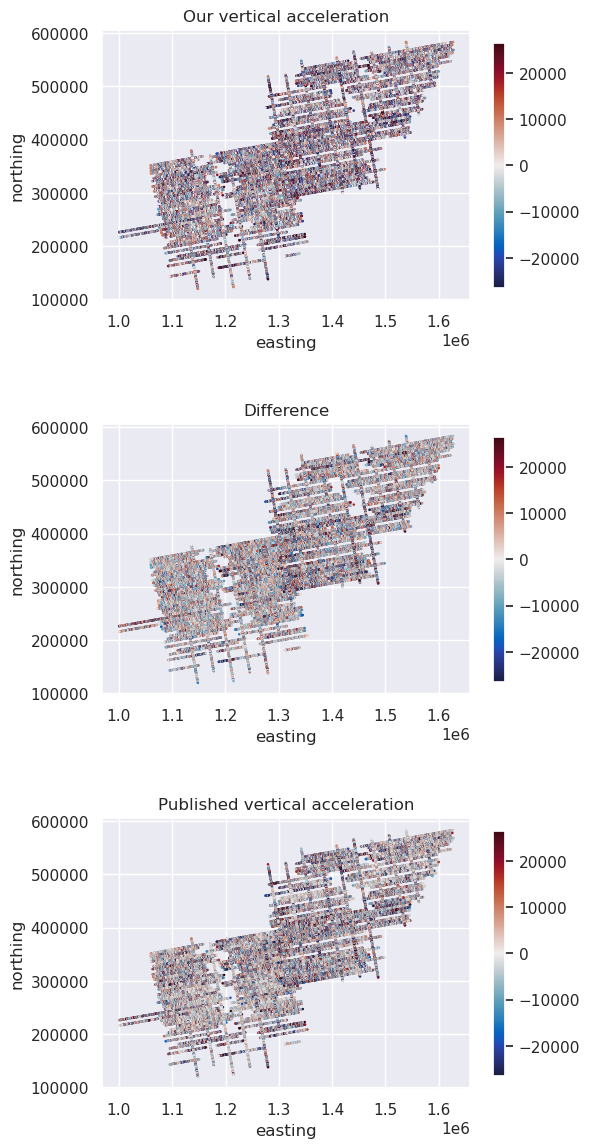

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(6, 12))

max_abs = vd.maxabs(data_df_full.VaccCor, percentile=95)

ax = data_df_full[::10].plot.scatter(
    "easting",
    "northing",
    c="vertical_acceleration",
    s=0.6,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Our vertical acceleration",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.8)

ax = data_df_full[::10].plot.scatter(
    "easting",
    "northing",
    c="difference",
    s=0.6,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Difference",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.8)

ax = data_df_full[::10].plot.scatter(
    "easting",
    "northing",
    c="VaccCor",
    s=0.6,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Published vertical acceleration",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

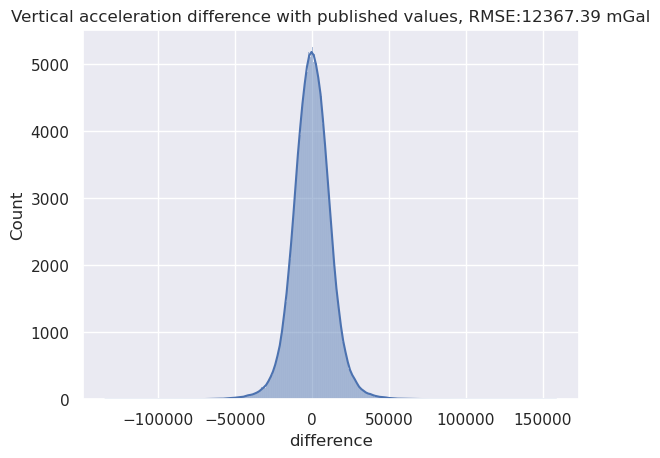

In [9]:
sns.histplot((data_df_full.difference), kde=True)
plt.title(
    f"Vertical acceleration difference with published values, RMSE:{round(airbornegeo.rmse(data_df_full.difference), 2)} mGal"
)
plt.show()